Shape BEFORE transpose:
(20, 11)

Rows before transpose: 20
Columns before transpose: 11

Original DataFrame:
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  

After set_index('Attribute'):
(20, 10)
                       Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
Attribute                                                                    
Mass (10^24kg)           0.330   4.87   5.97 

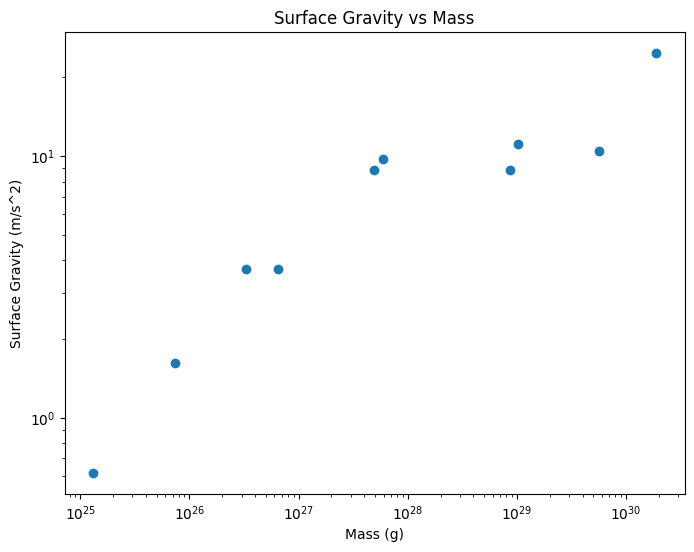

In [8]:
# homework10.ipynb

# ============================================================
# 2.1.1 Load and Inspect the Data
# ============================================================

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy import units as u
from astropy import constants as const

# Load CSV
df = pd.read_csv("solar_system.csv")

# ------------------------------------------------------------
# (a) Shape before transpose
# ------------------------------------------------------------
print("Shape BEFORE transpose:")
print(df.shape)

# ------------------------------------------------------------
# (b) Rows/columns before transpose
# ------------------------------------------------------------
print("\nRows before transpose:", df.shape[0])
print("Columns before transpose:", df.shape[1])

# ------------------------------------------------------------
# (c) Step-by-step transpose explanation
# ------------------------------------------------------------

print("\nOriginal DataFrame:")
print(df.head())

# Step 1
df = df.set_index("Attribute")

print("\nAfter set_index('Attribute'):")
print(df.shape)
print(df.head())

# Step 2
df = df.T

print("\nAfter transpose (.T):")
print(df.shape)
print(df.head())

# Step 3
df.index.name = "Planet"

print("\nAfter naming index:")
print(df.index.name)

# Step 4
df.reset_index(inplace=True)

print("\nAfter reset_index():")
print(df.shape)
print(df.head())

# Step 5
df.columns.name = None

print("\nAfter removing column name:")
print(df.columns)

# ------------------------------------------------------------
# Final shape
# ------------------------------------------------------------
print("\nShape AFTER transpose:")
print(df.shape)

print("\nRows after transpose:", df.shape[0])
print("Columns after transpose:", df.shape[1])

# ------------------------------------------------------------
# (d) Why isn't the shape (11,20)?
# ------------------------------------------------------------
print("""
The shape is not (11,20) because the 'Attribute' column became
the column headers after transposing. The structure changed so
that planets became rows and attributes became columns.
""")

# ------------------------------------------------------------
# (e) Print new column names
# ------------------------------------------------------------
print("\nColumn names:")
print(df.columns.tolist())

# ------------------------------------------------------------
# (f) Columns with units
# ------------------------------------------------------------

unit_columns = []
non_unit_columns = []

for col in df.columns:
    if "(" in col and ")" in col:
        unit_columns.append(col)
    else:
        non_unit_columns.append(col)

print("\nColumns WITH units:")
print(unit_columns)
print("Count:", len(unit_columns))

print("\nColumns WITHOUT units:")
print(non_unit_columns)
print("Count:", len(non_unit_columns))

# ------------------------------------------------------------
# (g) Print full transposed DataFrame
# ------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("\nFull transposed DataFrame:")
print(df)

# ============================================================
# 2.1.2 Investigate Data Types
# ============================================================

print("\n================================================")
print("DATA TYPES")
print("================================================")

# Current dtypes
print("\nColumn data types:")
print(df.dtypes)

# Inspect actual value types
print("\nInspecting actual value types in each column:")

for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].apply(type).value_counts())

print("""
(a) Most values are strings (str).

(b) Storing numbers as strings is a problem because:
- You cannot do math operations easily
- Statistics functions may fail
- Plotting and analysis become difficult
- Sorting may happen alphabetically instead of numerically
""")

# ============================================================
# 2.1.3 Convert Strings to Numbers
# ============================================================

# Convert numeric columns
for col in df.columns:
    if col not in ["Planet", "Ring System?", "Global Magnetic Field?"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Check dtypes again
print("\n================================================")
print("NEW DATA TYPES")
print("================================================")

print(df.dtypes)

print("""
(a) Three data types now:
- object
- int64
- float64

(b)
object  -> text/string data
int64   -> integer numbers
float64 -> decimal numbers

(c) Columns still stored as object:
- Planet
- Ring System?
- Global Magnetic Field?

These remain objects because they contain text values.
""")

# ============================================================
# 2.2 Apply Astropy Units
# ============================================================

def attach_units(column_name, unit, new_name=None, scale_factor=1):
    """
    Attach Astropy units to a column.
    """

    new_values = []

    for val in df[column_name]:
        if pd.notnull(val):
            new_values.append(val * scale_factor * unit)
        else:
            new_values.append(np.nan)

    df[column_name] = new_values

    if new_name is not None:
        df.rename(columns={column_name: new_name}, inplace=True)

# Example: Apply units to Mass column
attach_units(
    "Mass (10^24kg)",
    u.kg,
    new_name="Mass (kg)",
    scale_factor=1e24
)

print("\nMass column with units:")
print(df["Mass (kg)"])

# ============================================================
# 2.3 Data Analysis
# ============================================================

# ------------------------------------------------------------
# 1. Semi-Major Axis
# ------------------------------------------------------------

# Apply units first
attach_units(
    "Perihelion (10^6 km)",
    u.km,
    new_name="Perihelion (km)",
    scale_factor=1e6
)

attach_units(
    "Aphelion (10^6 km)",
    u.km,
    new_name="Aphelion (km)",
    scale_factor=1e6
)

# Compute semi-major axis
semi_major = (df["Perihelion (km)"] + df["Aphelion (km)"]) / 2

# Insert after Aphelion column
aphelion_index = df.columns.get_loc("Aphelion (km)")

df.insert(
    aphelion_index + 1,
    "Semi-Major Axis (km)",
    semi_major
)

print("\nColumn names after inserting semi-major axis:")
print(df.columns.tolist())

print("\nSemi-Major Axis column:")
print(df["Semi-Major Axis (km)"])

# ------------------------------------------------------------
# 2. Convert Orbital Period to Years
# ------------------------------------------------------------

attach_units(
    "Orbital Period (days)",
    u.day,
    new_name="Orbital Period (years)"
)

# Convert to years
df["Orbital Period (years)"] = [
    val.to(u.year) if pd.notnull(val) else np.nan
    for val in df["Orbital Period (years)"]
]

print("\nColumn names after orbital period conversion:")
print(df.columns.tolist())

print("\nOrbital Period in years:")
print(df["Orbital Period (years)"])

# Favorite planet example
favorite_planet = "Earth"

earth_period = df.loc[
    df["Planet"] == favorite_planet,
    "Orbital Period (years)"
].iloc[0]

print(f"\n{favorite_planet}'s orbital period:")
print(f"{earth_period:.4f}")

# ------------------------------------------------------------
# 3. Convert Distance Columns to AU
# ------------------------------------------------------------

distance_columns = [
    "Diameter (km)",
    "Perihelion (km)",
    "Aphelion (km)",
    "Semi-Major Axis (km)"
]

for col in distance_columns:

    new_vals = []

    for val in df[col]:

        if pd.notnull(val):

            # If value already has units
            if hasattr(val, "to"):
                new_vals.append(val.to(u.au))

            # If value is plain number
            else:
                new_vals.append((val * u.km).to(u.au))

        else:
            new_vals.append(np.nan)

    df[col] = new_vals

    new_name = col.replace("(km)", "(AU)")
    df.rename(columns={col: new_name}, inplace=True)

print("\nConverted distance columns:")
print(df.columns.tolist())

# Print sample values for favorite planet
print(f"\nDistance values for {favorite_planet}:")

earth_row = df[df["Planet"] == favorite_planet]

for col in df.columns:
    if "(AU)" in col:
        print(col, ":", earth_row[col].iloc[0])

# ============================================================
# BONUS: Surface Gravity vs Mass Plot
# ============================================================

# Radius = diameter / 2
radius_m = []

for val in df["Diameter (AU)"]:
    if pd.notnull(val):
        radius_m.append((val.to(u.m)) / 2)
    else:
        radius_m.append(np.nan)

# Mass in grams
mass_g = []

for val in df["Mass (kg)"]:
    if pd.notnull(val):
        mass_g.append(val.to(u.g))
    else:
        mass_g.append(np.nan)

# Compute gravity
gravity_vals = []

for m, r in zip(mass_g, radius_m):

    if pd.notnull(m) and pd.notnull(r):

        g = const.G * m.to(u.kg) / (r**2)

        gravity_vals.append(g.to(u.m / u.s**2).value)

    else:
        gravity_vals.append(np.nan)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    [m.value for m in mass_g],
    gravity_vals
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Mass (g)")
plt.ylabel("Surface Gravity (m/s^2)")
plt.title("Surface Gravity vs Mass")

plt.show()